In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e8/sample_submission.csv
/kaggle/input/playground-series-s5e8/train.csv
/kaggle/input/playground-series-s5e8/test.csv


In [2]:
import pandas as pd

# File paths
train_path = "/kaggle/input/playground-series-s5e8/train.csv"
test_path = "/kaggle/input/playground-series-s5e8/test.csv"
submission_path = "/kaggle/input/playground-series-s5e8/sample_submission.csv"

# Reading CSV files
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
submission_df = pd.read_csv(submission_path)


print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", submission_df.shape)

Train shape: (750000, 18)
Test shape: (250000, 17)
Sample submission shape: (250000, 2)


In [3]:

print("Train Data Sample:")
print(train_df.head())

print("\nTest Data Sample:")
print(test_df.head())

print("\nSample Submission:")
print(submission_df.head())

Train Data Sample:
   id  age          job  marital  education default  balance housing loan  \
0   0   42   technician  married  secondary      no        7      no   no   
1   1   38  blue-collar  married  secondary      no      514      no   no   
2   2   36  blue-collar  married  secondary      no      602     yes   no   
3   3   27      student   single  secondary      no       34     yes   no   
4   4   26   technician  married  secondary      no      889     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome  y  
0  cellular   25   aug       117         3     -1         0  unknown  0  
1   unknown   18   jun       185         1     -1         0  unknown  0  
2   unknown   14   may       111         2     -1         0  unknown  0  
3   unknown   28   may        10         2     -1         0  unknown  0  
4  cellular    3   feb       902         1     -1         0  unknown  1  

Test Data Sample:
       id  age            job  marital  education defau

In [4]:
# Check data types and non-null counts
print("\n🔹 Train Data Info:")
print(train_df.info())

# Check for missing/null values
print("\n🔹 Null Values in Train Data:")
print(train_df.isnull().sum())

# Check categorical and numerical features
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('y')  # Exclude target

print("\n🔹 Categorical Columns:", categorical_cols)
print("🔹 Numerical Columns:", numerical_cols)


🔹 Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB
None

🔹 Null Valu

In [5]:


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)



# Target Variable Distribution

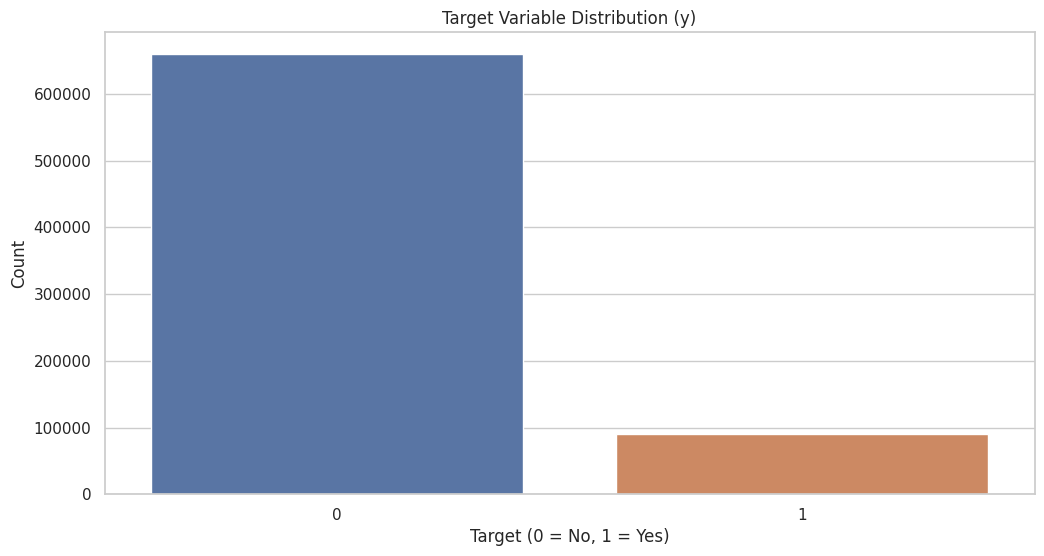

🔹 Target Distribution (Counts):
y
0    659512
1     90488
Name: count, dtype: int64

🔹 Target Distribution (Percentage):
y
0    87.934933
1    12.065067
Name: proportion, dtype: float64


In [6]:
# 2. Target Variable Distribution
sns.countplot(x='y', data=train_df)
plt.title("Target Variable Distribution (y)")
plt.xlabel("Target (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Display value counts and percentage
print("🔹 Target Distribution (Counts):")
print(train_df['y'].value_counts())
print("\n🔹 Target Distribution (Percentage):")
print(train_df['y'].value_counts(normalize=True) * 100)

# Univariate Analysis

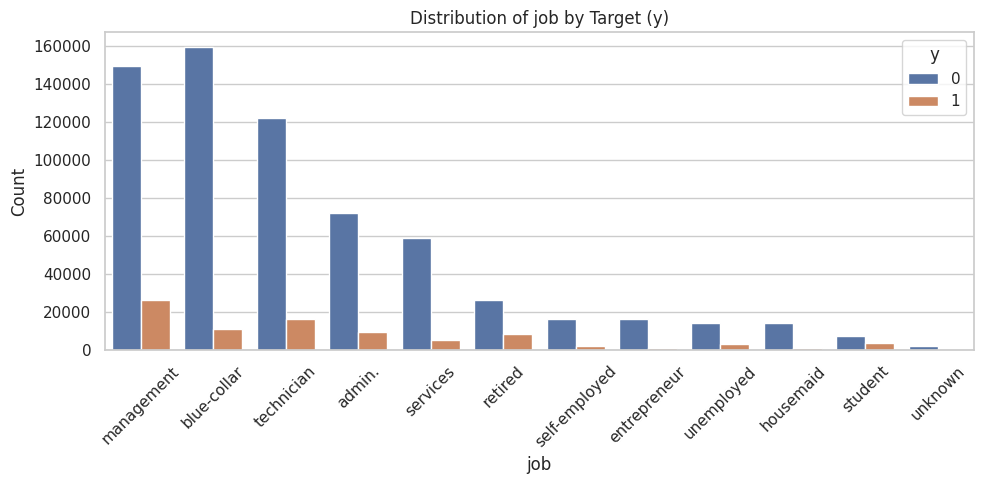

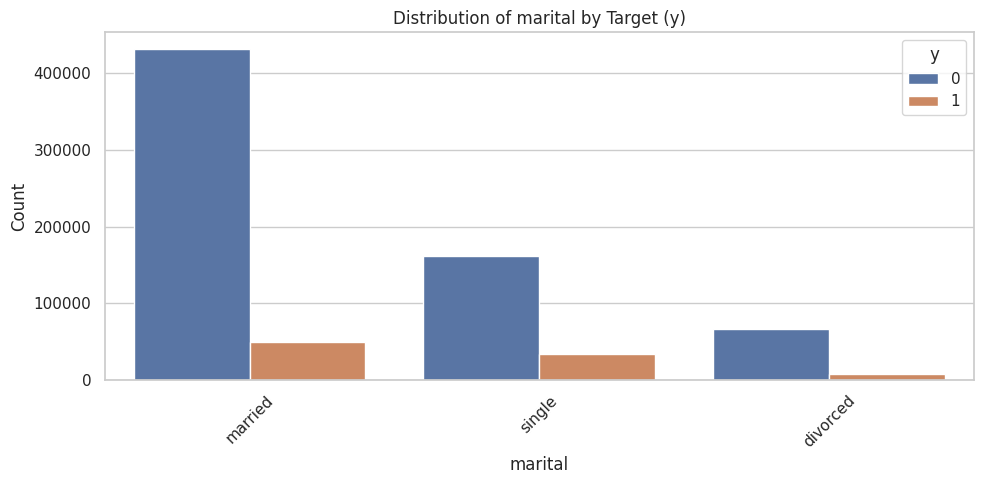

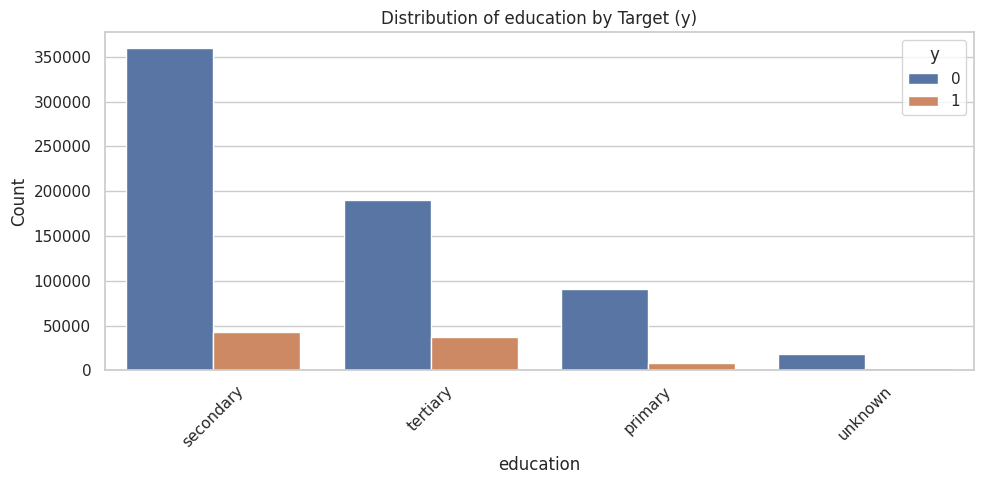

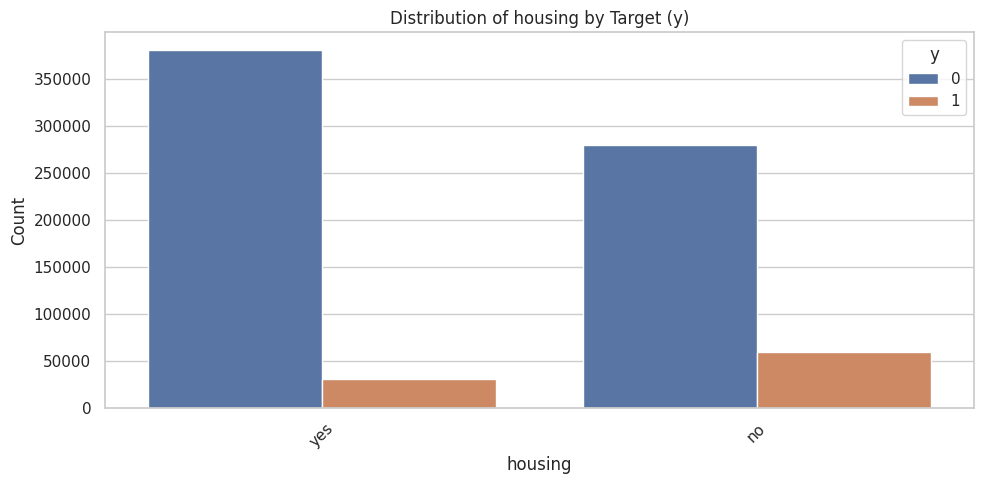

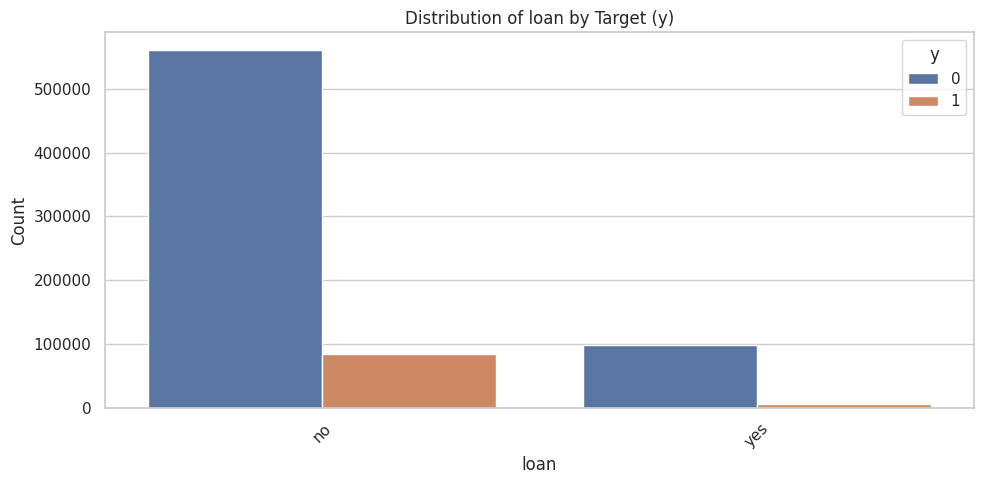

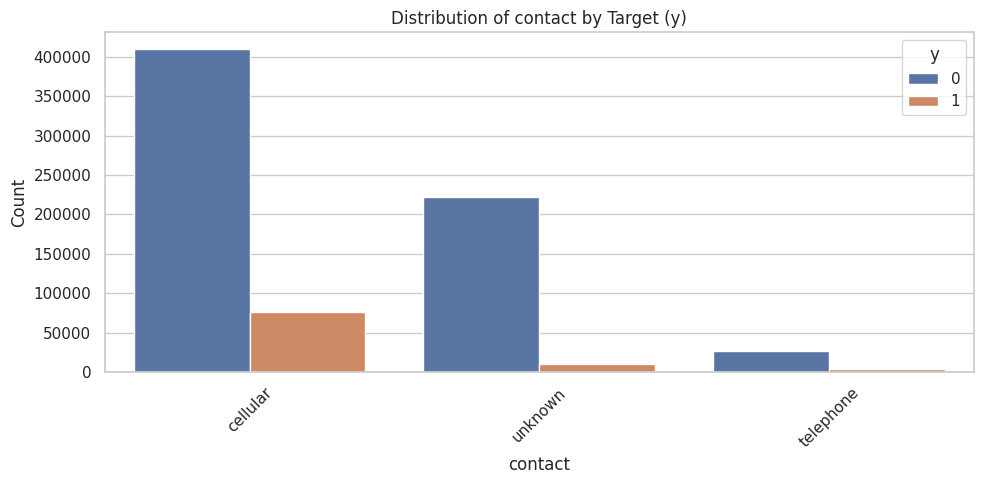

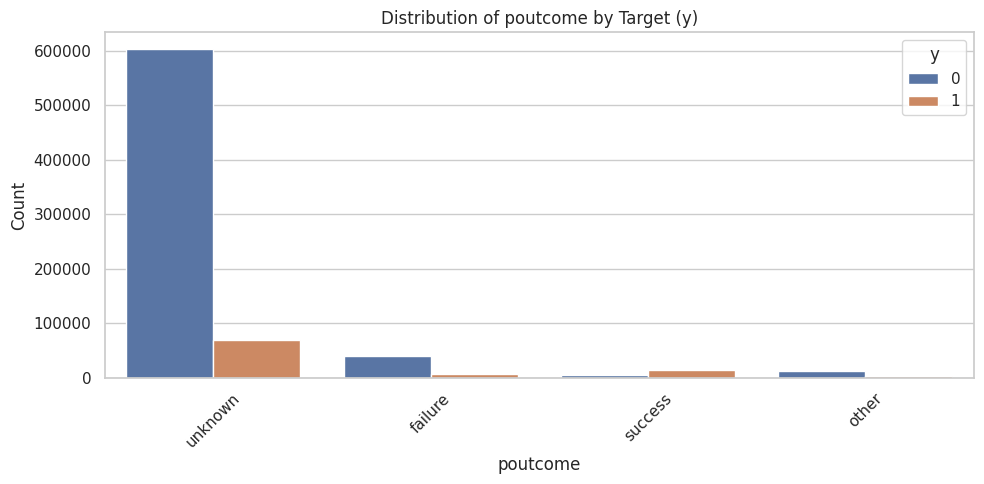

In [7]:
#  Categorical Feature Distributions by Target
cat_features = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'poutcome']

for col in cat_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=train_df, x=col, hue='y', order=train_df[col].value_counts().index)
    plt.title(f"Distribution of {col} by Target (y)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title='y', loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

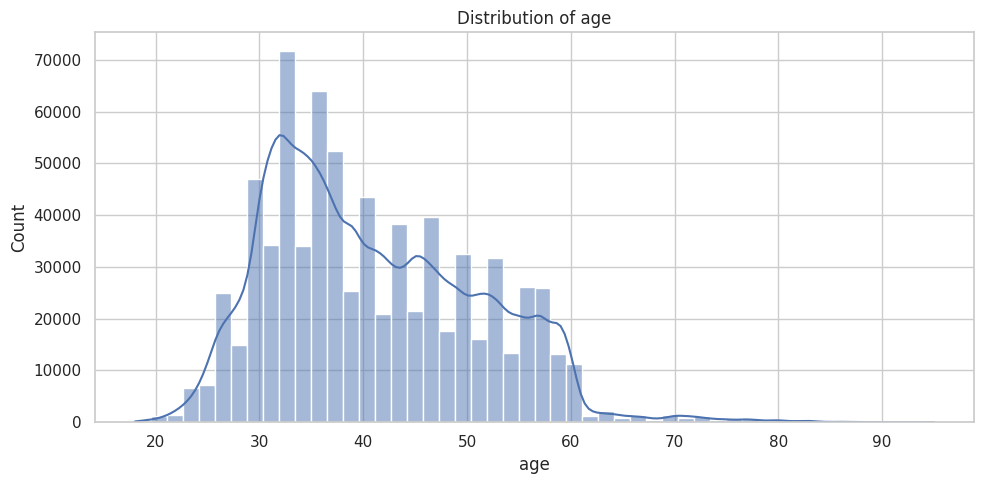

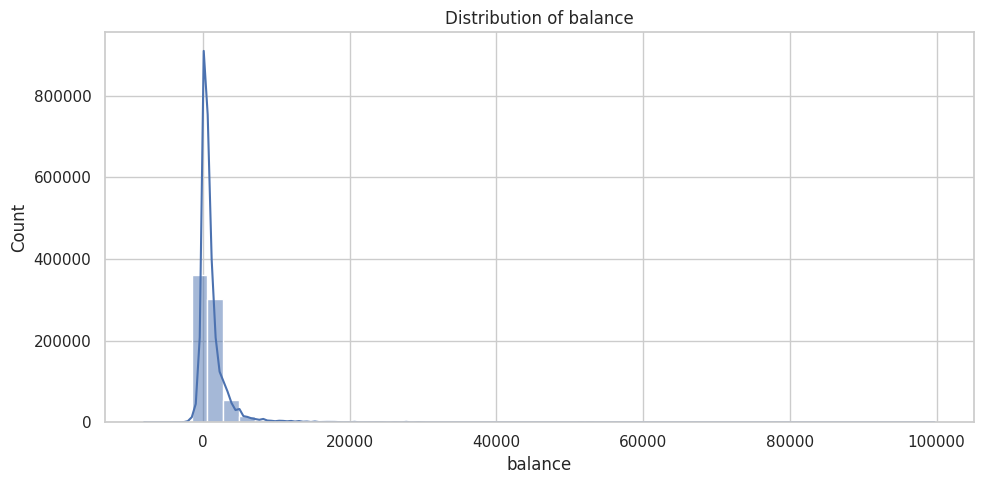

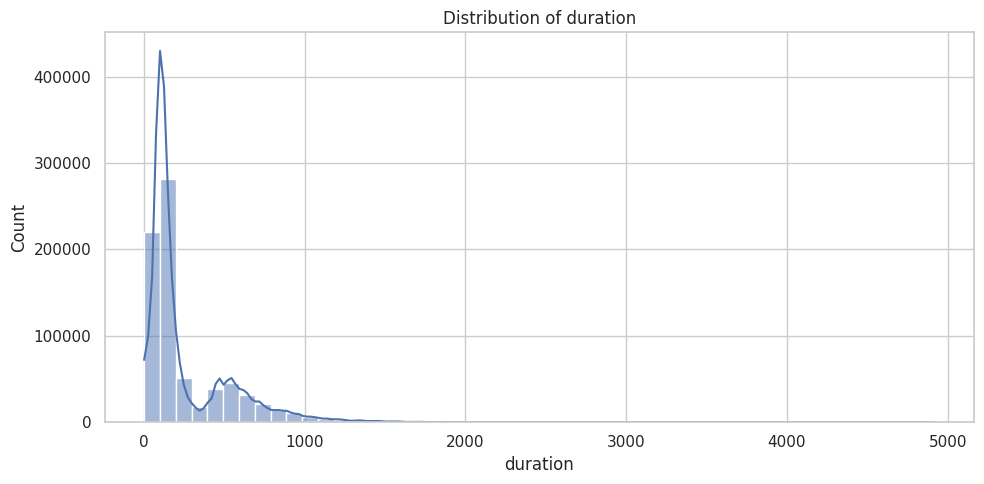

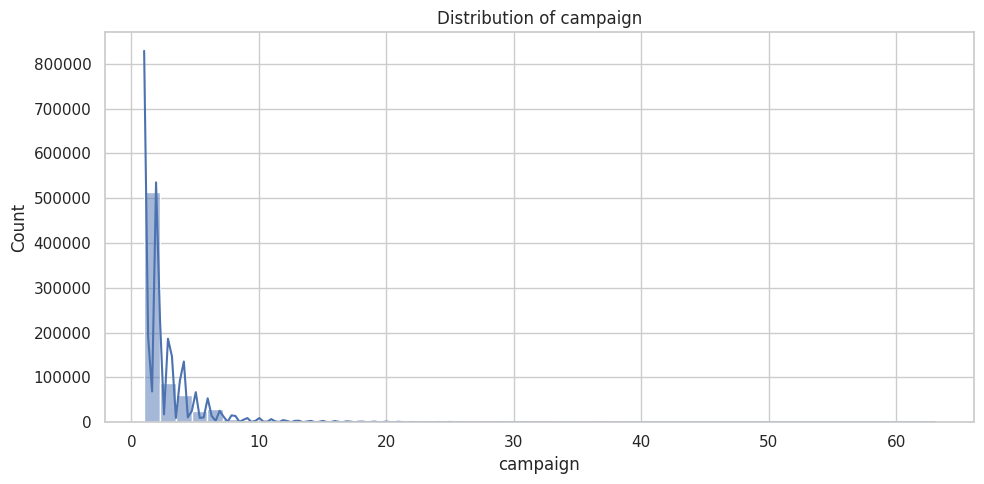

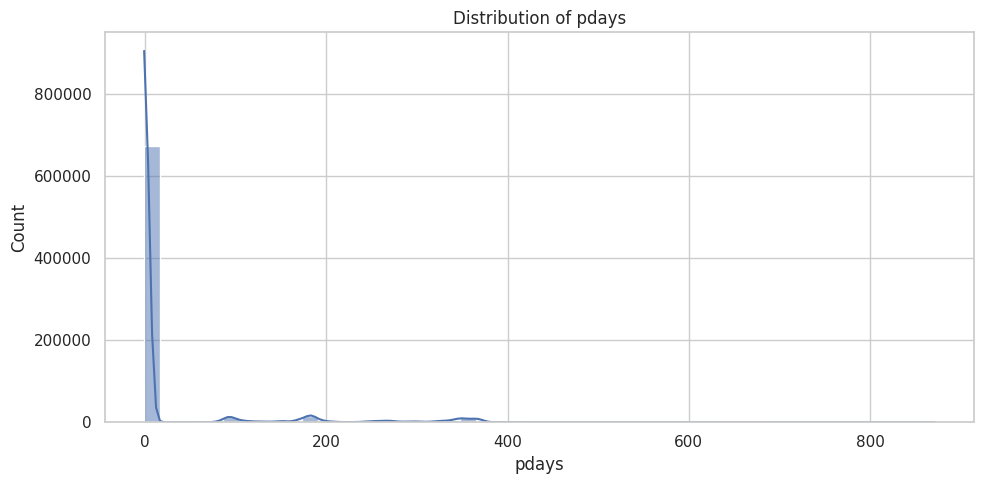

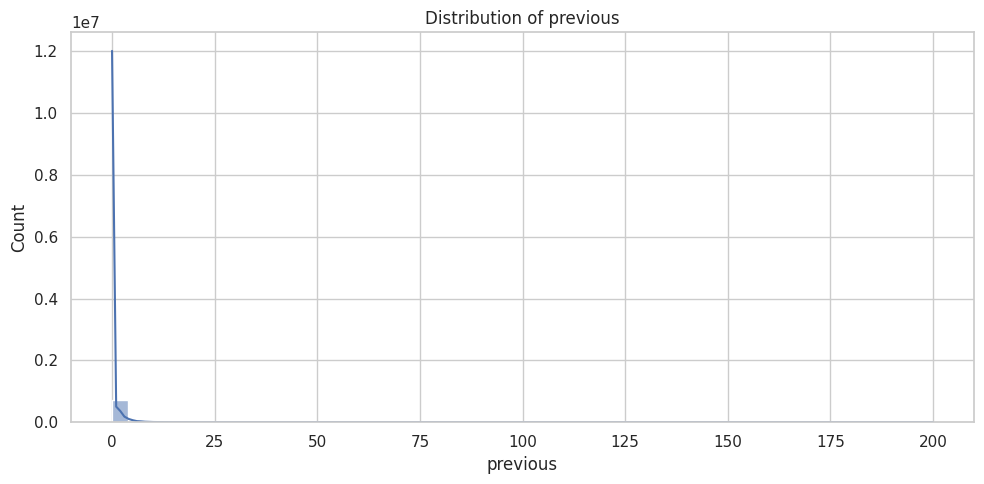

In [8]:
#  Numerical Feature Distributions
num_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Histograms and KDEs
for col in num_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(train_df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

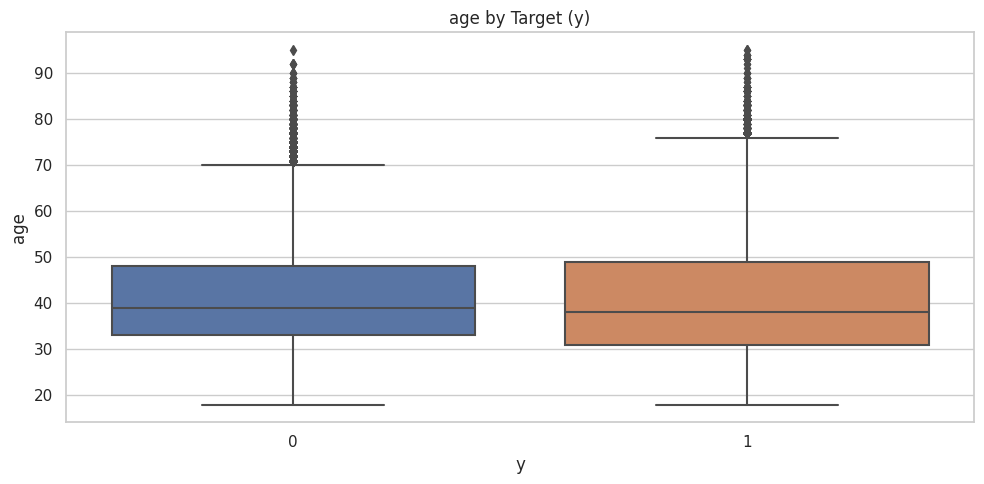

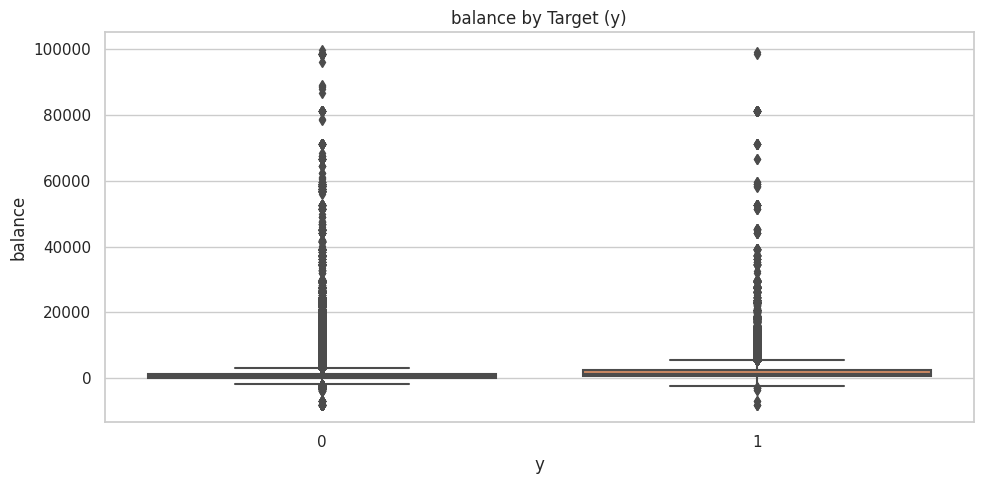

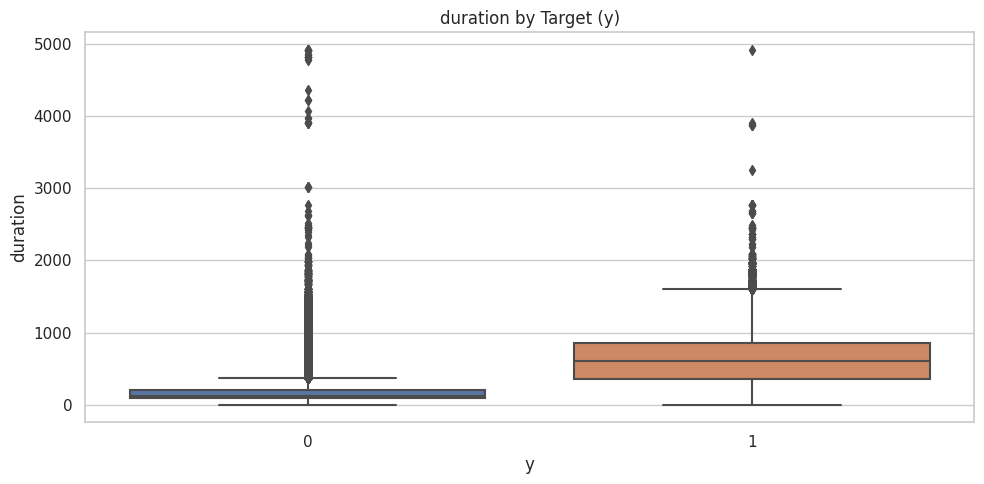

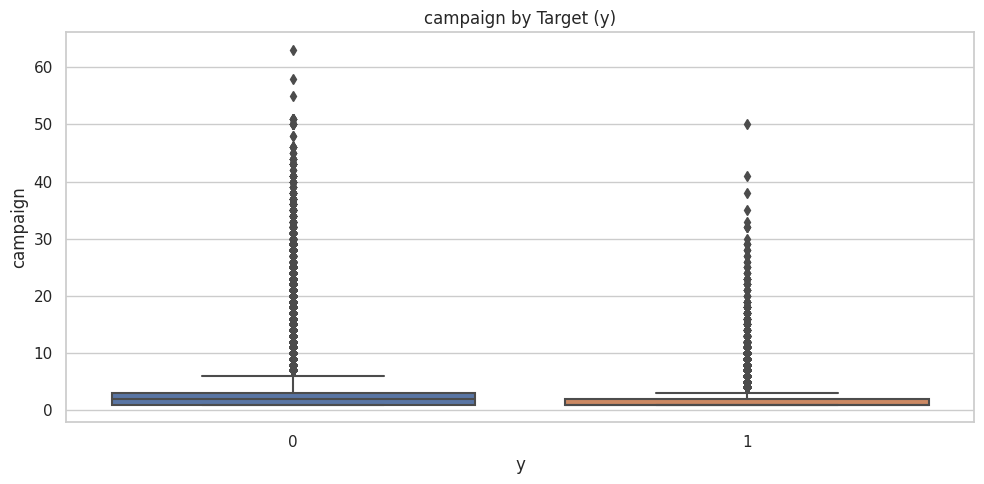

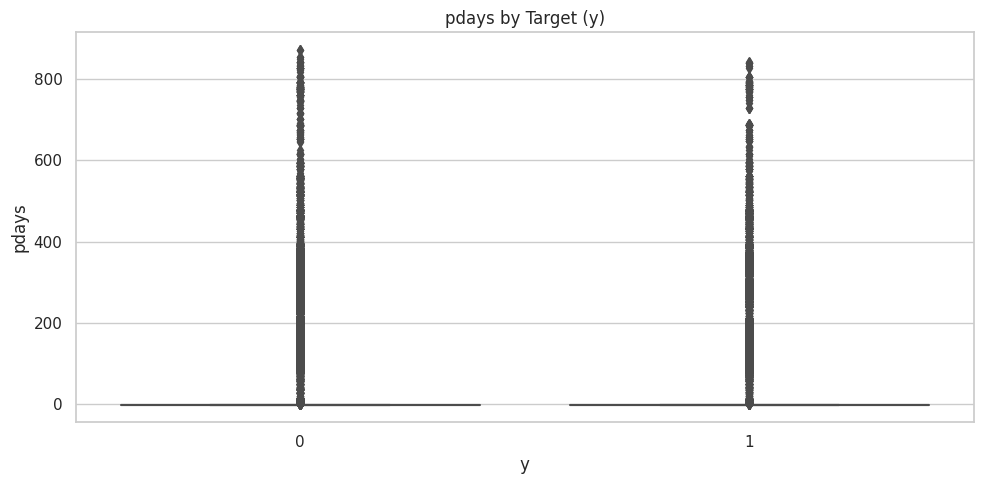

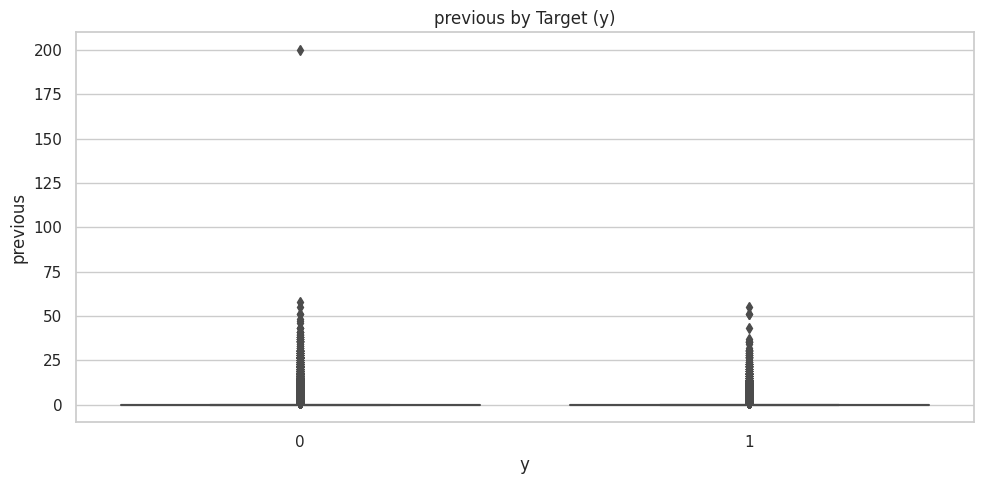

In [9]:
# Box plots split by target
for col in num_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=train_df, x='y', y=col)
    plt.title(f"{col} by Target (y)")
    plt.xlabel("y")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Bivariate Analysis

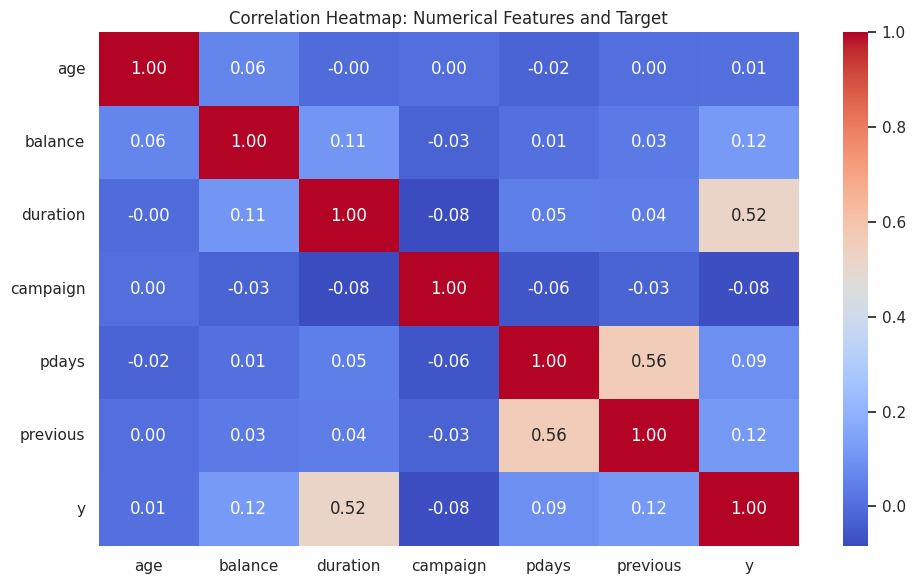

In [10]:
# Correlation matrix (numerical features + target)
plt.figure(figsize=(10, 6))
corr = train_df[num_features + ['y']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Numerical Features and Target")
plt.tight_layout()
plt.show()

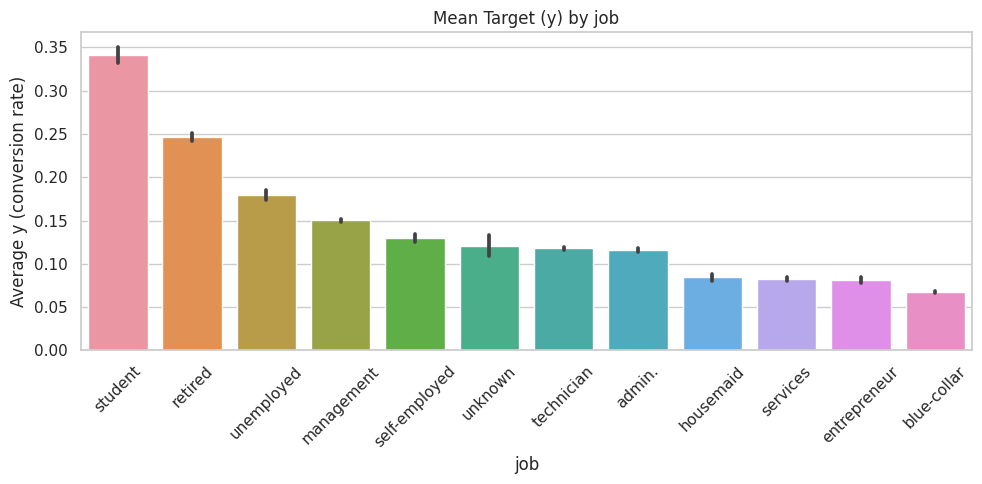

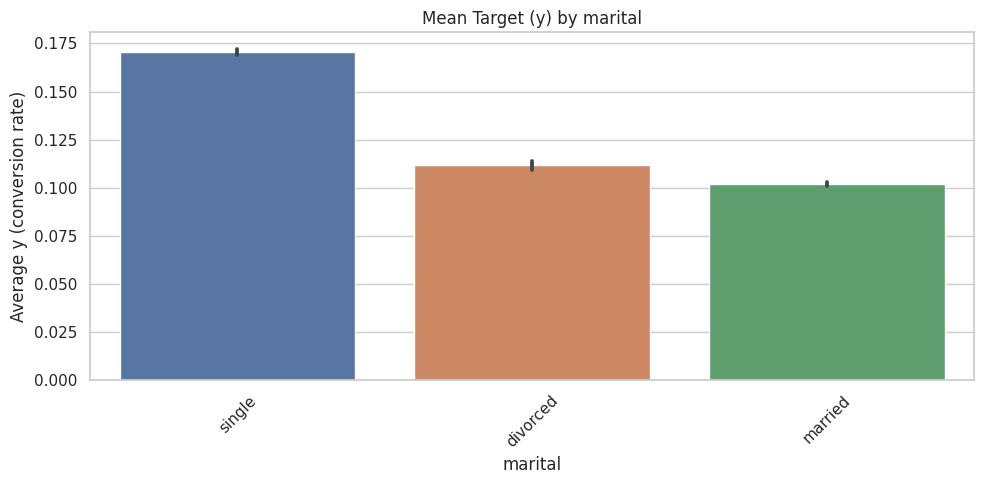

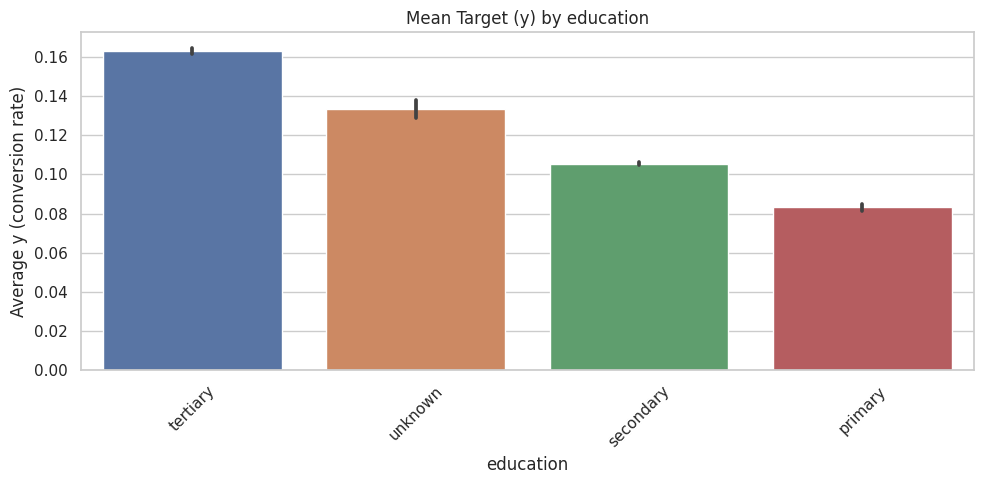

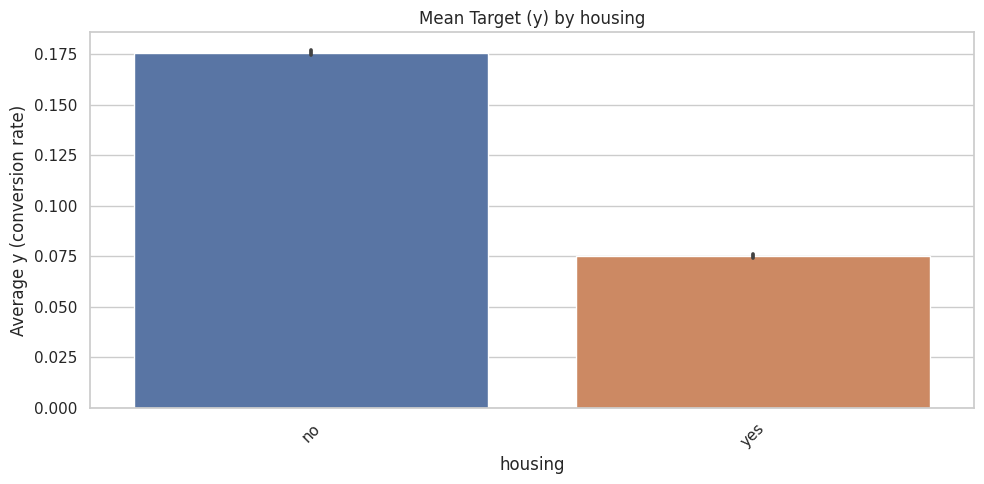

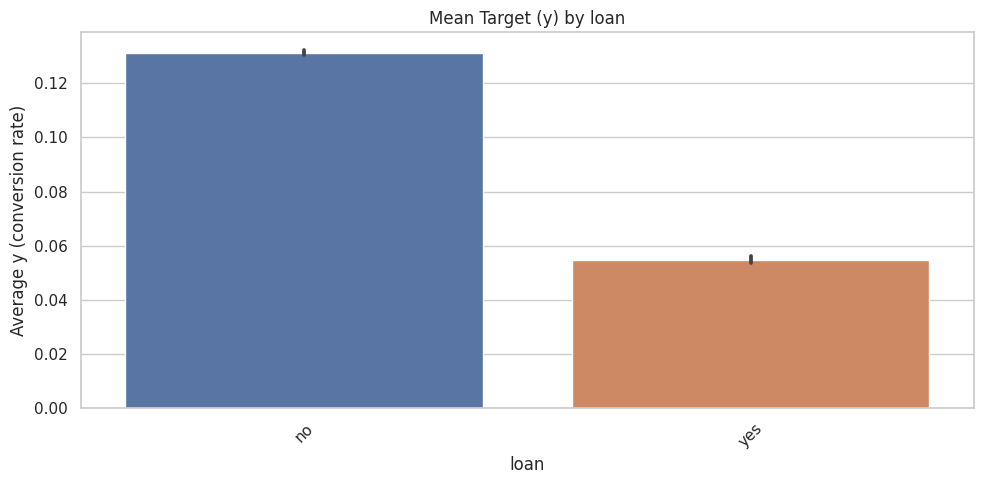

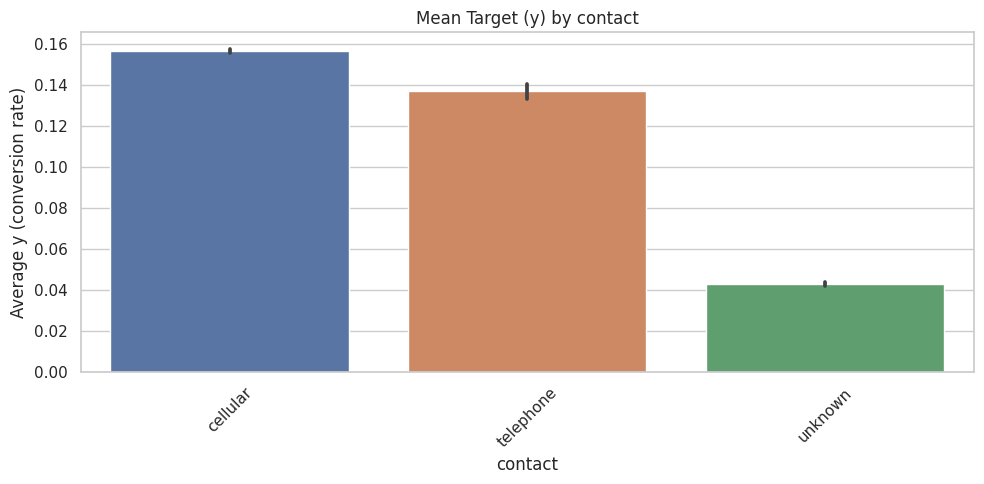

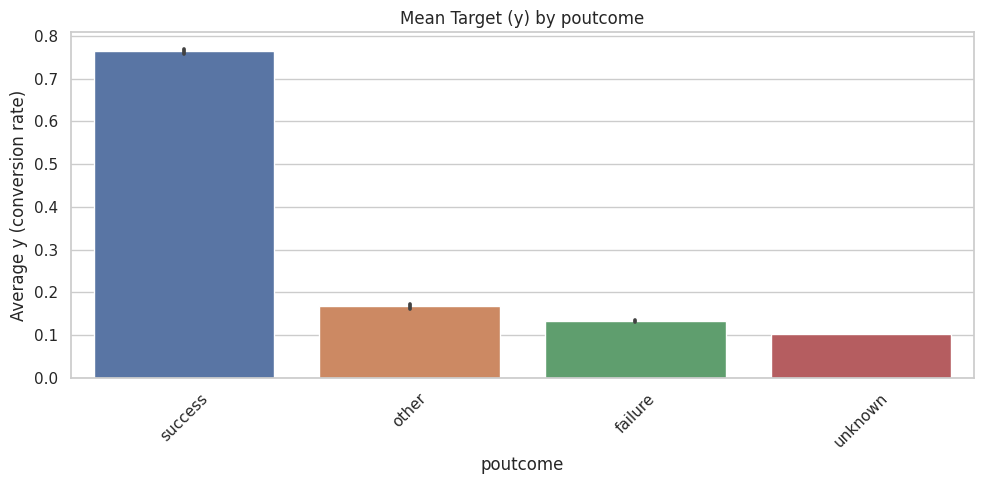

In [11]:
# Mean conversion rate by category
for col in cat_features:
    plt.figure(figsize=(10, 5))
    order = train_df.groupby(col)['y'].mean().sort_values(ascending=False).index
    sns.barplot(x=col, y='y', data=train_df, order=order)
    plt.title(f"Mean Target (y) by {col}")
    plt.ylabel("Average y (conversion rate)")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


🔹 Crosstab: Marital vs Loan (Row-normalized):
loan            no       yes
marital                     
divorced  0.840741  0.159259
married   0.851142  0.148858
single    0.889331  0.110669


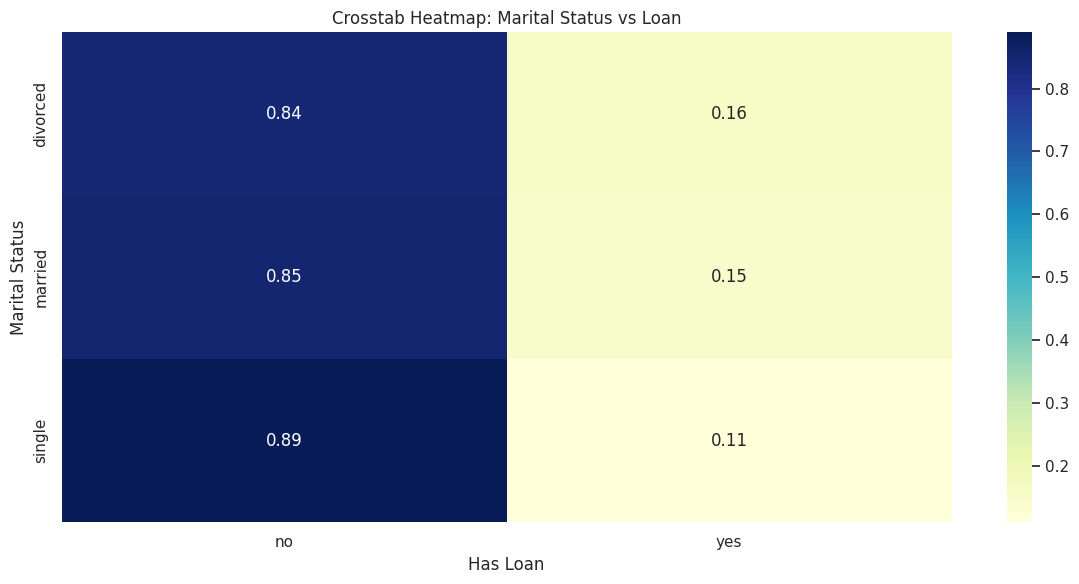

In [12]:
# Cross-tab: marital vs loan
ct = pd.crosstab(train_df['marital'], train_df['loan'], normalize='index')
print("\n🔹 Crosstab: Marital vs Loan (Row-normalized):")
print(ct)

# Heatmap of above cross-tab
sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Crosstab Heatmap: Marital Status vs Loan")
plt.ylabel("Marital Status")
plt.xlabel("Has Loan")
plt.tight_layout()
plt.show()

# Outlier Detection

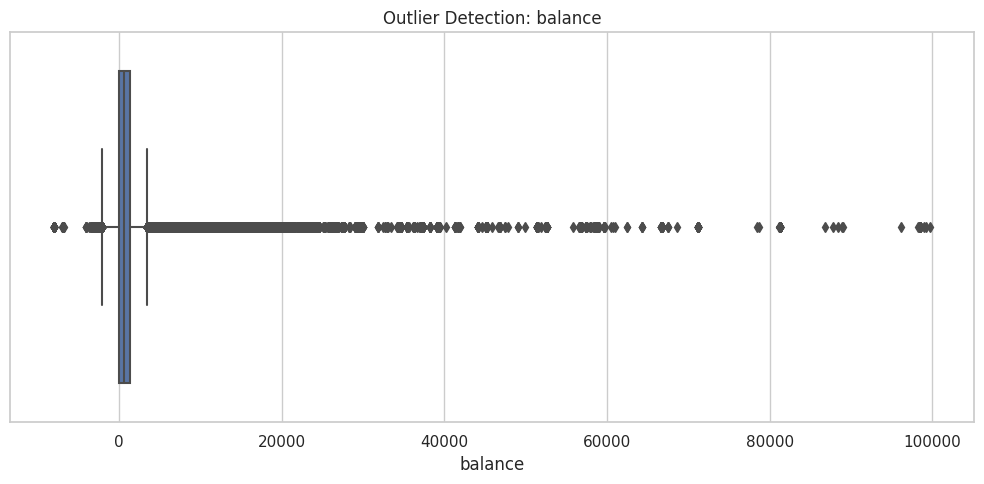

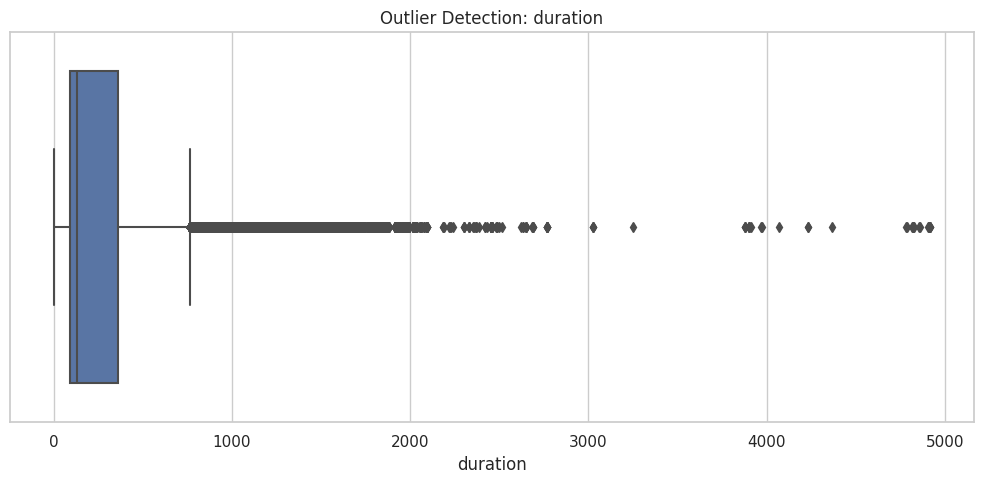

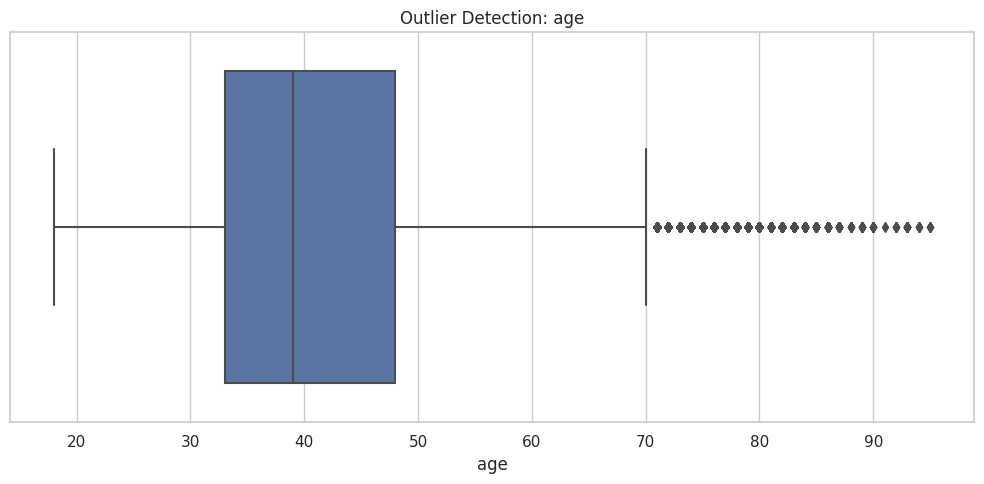

In [13]:
# Outlier detection for balance, duration, and age
outlier_cols = ['balance', 'duration', 'age']

for col in outlier_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=train_df[col])
    plt.title(f'Outlier Detection: {col}')
    plt.tight_layout()
    plt.show()

In [14]:
# Display 1st and 99th percentiles
for col in outlier_cols:
    q01 = train_df[col].quantile(0.01)
    q99 = train_df[col].quantile(0.99)
    print(f"{col}: 1st percentile = {q01}, 99th percentile = {q99}")

balance: 1st percentile = -974.0, 99th percentile = 10861.0
duration: 1st percentile = 7.0, 99th percentile = 1206.0
age: 1st percentile = 24.0, 99th percentile = 66.0


# Missing/Unknown Values

job: 2917 unknowns (0.39%)
education: 21299 unknowns (2.84%)
contact: 231627 unknowns (30.88%)
poutcome: 672450 unknowns (89.66%)


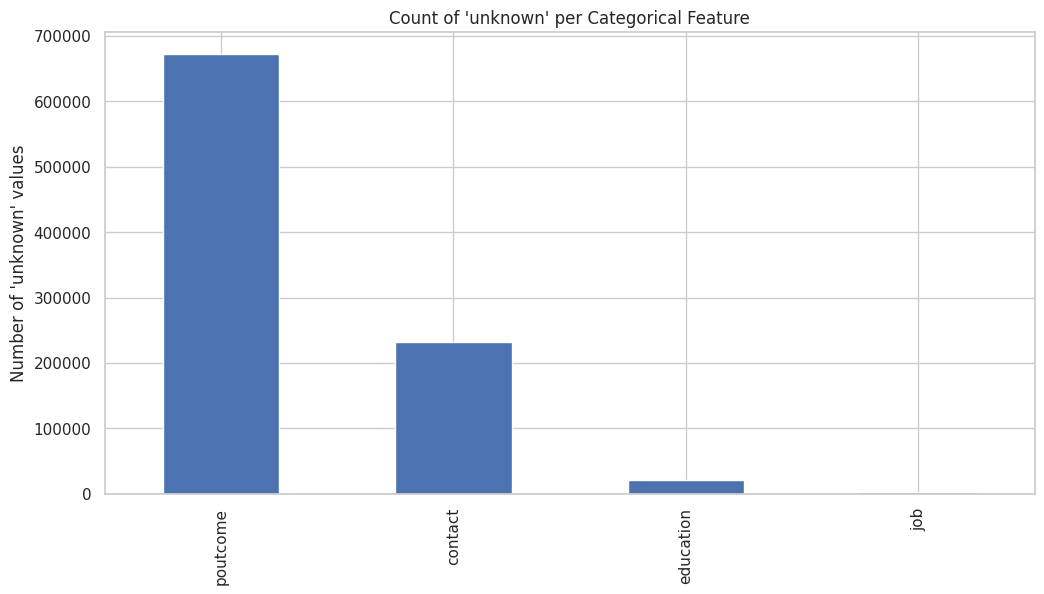

In [15]:
# Check how many 'unknown' values per categorical column
unknown_counts = {}

for col in categorical_cols:
    count = (train_df[col] == 'unknown').sum()
    if count > 0:
        unknown_counts[col] = count

# Print counts
for col, count in unknown_counts.items():
    print(f"{col}: {count} unknowns ({(count / len(train_df)) * 100:.2f}%)")

# Barplot
if unknown_counts:
    pd.Series(unknown_counts).sort_values(ascending=False).plot(kind='bar')
    plt.title("Count of 'unknown' per Categorical Feature")
    plt.ylabel("Number of 'unknown' values")
    plt.show()

# Feature Engineering Opportunities

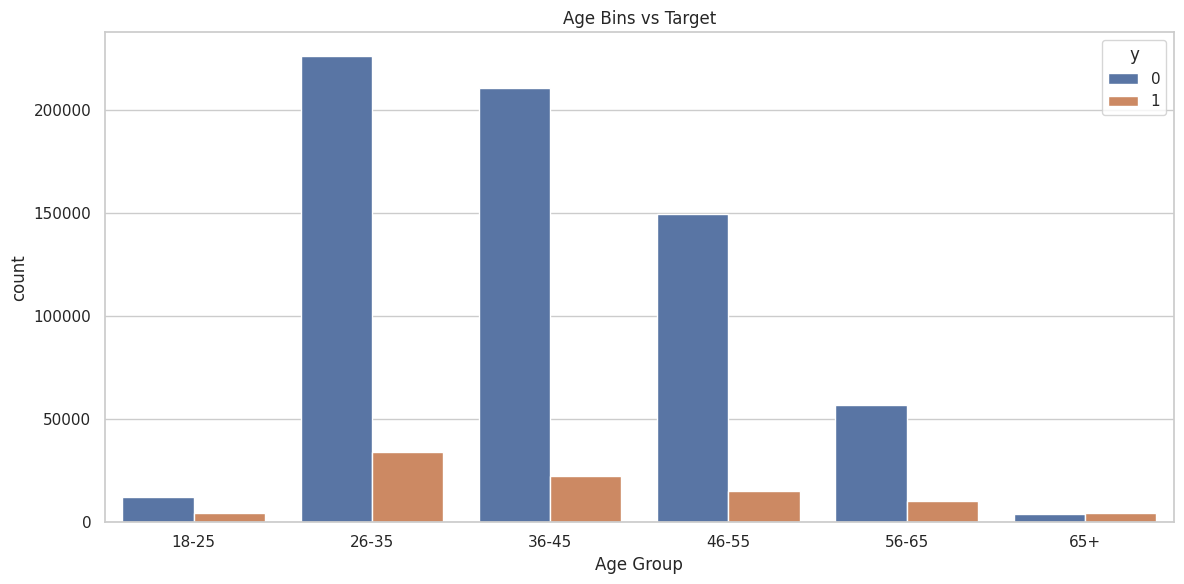

In [16]:
train_df['age_bin'] = pd.cut(train_df['age'], bins=[17, 25, 35, 45, 55, 65, 100], labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])
sns.countplot(x='age_bin', data=train_df, hue='y')
plt.title("Age Bins vs Target")
plt.xlabel("Age Group")
plt.tight_layout()
plt.show()

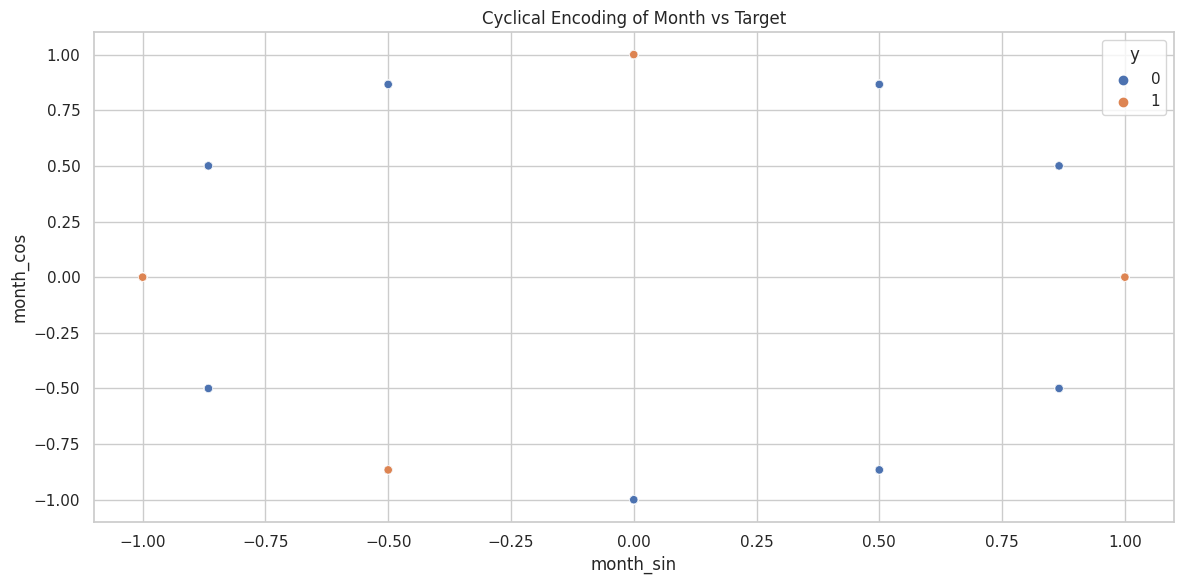

In [17]:
# Mapping month to numerical value
month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
             'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}

train_df['month_num'] = train_df['month'].map(month_map)

# Cyclical encoding
train_df['month_sin'] = np.sin(2 * np.pi * train_df['month_num'] / 12)
train_df['month_cos'] = np.cos(2 * np.pi * train_df['month_num'] / 12)

sns.scatterplot(x='month_sin', y='month_cos', hue='y', data=train_df)
plt.title("Cyclical Encoding of Month vs Target")
plt.tight_layout()
plt.show()

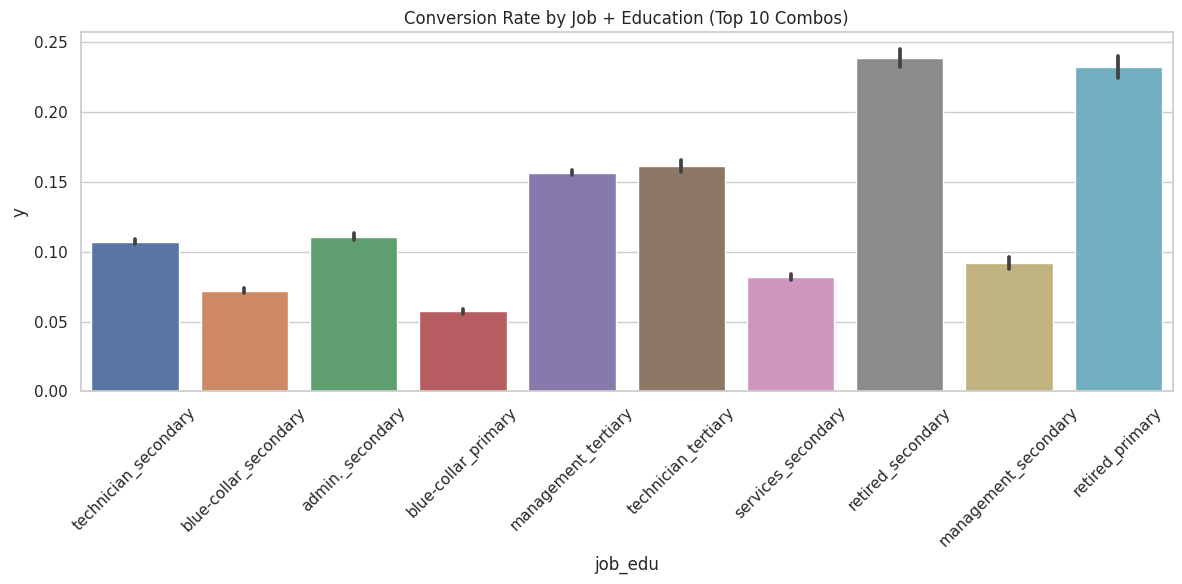

In [18]:
# Combine job and education as an interaction
train_df['job_edu'] = train_df['job'] + "_" + train_df['education']
top_10_combo = train_df['job_edu'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.barplot(x='job_edu', y='y', data=train_df[train_df['job_edu'].isin(top_10_combo)])
plt.title("Conversion Rate by Job + Education (Top 10 Combos)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Class imbalance checks with ROC AUC

In [19]:
target_ratio = train_df['y'].value_counts(normalize=True)
print(f"Target Balance:\n{target_ratio}")

Target Balance:
y
0    0.879349
1    0.120651
Name: proportion, dtype: float64


In [20]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['y'])):
    print(f"Fold {fold + 1}:")
    print(f"  Train size: {len(train_idx)}, Validation size: {len(val_idx)}")

Fold 1:
  Train size: 600000, Validation size: 150000
Fold 2:
  Train size: 600000, Validation size: 150000
Fold 3:
  Train size: 600000, Validation size: 150000
Fold 4:
  Train size: 600000, Validation size: 150000
Fold 5:
  Train size: 600000, Validation size: 150000


In [21]:
X = train_df.drop("y", axis=1)
y = train_df["y"]

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print(f"Fold {fold+1}:")
    print("Train shape:", X_train.shape, "Val shape:", X_val.shape)


Fold 1:
Train shape: (600000, 22) Val shape: (150000, 22)
Fold 2:
Train shape: (600000, 22) Val shape: (150000, 22)
Fold 3:
Train shape: (600000, 22) Val shape: (150000, 22)
Fold 4:
Train shape: (600000, 22) Val shape: (150000, 22)
Fold 5:
Train shape: (600000, 22) Val shape: (150000, 22)


Model Training

In [22]:
from xgboost import XGBClassifier

# Convert object columns to category
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# Same for test_df
for col in test_df.select_dtypes(include="object").columns:
    test_df[col] = test_df[col].astype("category")

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss",
    enable_categorical=True  
)


In [23]:
from sklearn.metrics import accuracy_score
import numpy as np

scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        enable_categorical=True
    )

    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    scores.append(acc)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

print("\nMean CV Accuracy:", np.mean(scores))


Fold 1 Accuracy: 0.9353
Fold 2 Accuracy: 0.9345
Fold 3 Accuracy: 0.9349
Fold 4 Accuracy: 0.9350
Fold 5 Accuracy: 0.9343

Mean CV Accuracy: 0.9348013333333334


In [24]:
final_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    enable_categorical=True
)

final_model.fit(X, y)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

# Feature Engineering

In [25]:
# Age binning → convert to category or string
train_df["age_bin"] = pd.cut(
    train_df["age"],
    bins=[0, 25, 35, 50, 100],
    labels=["Young", "Adult", "MidAge", "Senior"]
).astype(str)

test_df["age_bin"] = pd.cut(
    test_df["age"],
    bins=[0, 25, 35, 50, 100],
    labels=["Young", "Adult", "MidAge", "Senior"]
).astype(str)

# Month number (convert to int, not category)
month_map = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}

train_df["month_num"] = train_df["month"].map(month_map).astype(int)
test_df["month_num"] = test_df["month"].map(month_map).astype(int)

# Cyclical encoding of month
train_df["month_sin"] = np.sin(2 * np.pi * train_df["month_num"] / 12)
train_df["month_cos"] = np.cos(2 * np.pi * train_df["month_num"] / 12)

test_df["month_sin"] = np.sin(2 * np.pi * test_df["month_num"] / 12)
test_df["month_cos"] = np.cos(2 * np.pi * test_df["month_num"] / 12)

# Job + Education combined (keep as string)
train_df["job_edu"] = train_df["job"].astype(str) + "_" + train_df["education"].astype(str)
test_df["job_edu"] = test_df["job"].astype(str) + "_" + test_df["education"].astype(str)

# Convert object columns to category for *both* train and test after feature engineering
for col in train_df.select_dtypes(include="object").columns:
    train_df[col] = train_df[col].astype("category")

for col in test_df.select_dtypes(include="object").columns:
    test_df[col] = test_df[col].astype("category")


# Submission

In [26]:
# Align columns - crucial for consistent feature sets
X_train_cols = X.columns
test_aligned = test_df[X_train_cols]


# Predict probabilities instead of class labels
test_probs = final_model.predict_proba(test_aligned)[:, 1]

# Save in submission format
submission_df["y"] = test_probs
submission_df.to_csv("submission.csv", index=False)

print("✅ Submission file with probabilities saved as submission.csv")
print(submission_df.head())


✅ Submission file with probabilities saved as submission.csv
       id         y
0  750000  0.001895
1  750001  0.097492
2  750002  0.000330
3  750003  0.000087
4  750004  0.026617
